# Aprendiendo Fashion-MNIST con PyTorch

## Refs.

* https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html

* https://github.com/zalandoresearch/fashion-mnist

* https://github.com/pranay414/Fashion-MNIST-Pytorch/blob/master/fashion_mnist.ipynb

## **Ejercicio 1)** Importando librerías

**0)** De ser necesario, **instale PyTorch** escribiendo

    !pip3 install torch torchvision torchaudio torchviz

**1)** Importe las librerías estandard de Python: `os`, `datetime`, `collections` y `pickle`.

**2)** Importe las siguientes librerías third party de Python: `matplotlib.pyplot`, `numpy`, `scipy`, `sklearn`, `pandas`, `dill` y `json`.

**3)** Importe las librerias necesarias de **PyTorch**: `torch` y `torchvision`.

**4)** Importe la librería: `google.colab`.

In [1]:
# 1.0)
#!pip3 install torch torchvision torchaudio torchviz

In [2]:
# 1.1)
import os
import pickle
import datetime
from collections import defaultdict

In [3]:
# 1.2)
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import sklearn as skl
import pandas as pd
#import dill
import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
# 1.3)
import torch
import torch.optim as optim
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import datasets
from torchvision import transforms
from torchvision.io import read_image
from torchvision.transforms import ToTensor, Lambda, Compose
#from torchviz import make_dot

## **Ejercicio 2)**

Bajando y Jugando con el dataset **Fashion-MNIST**.

**1)** Baje y transforme (i.e. normalize los valores de los pixeles) los conjuntos de entrenamiento y testeo de FashionMNIST.

**2)** Explore algunos ejemplos de estos conjuntos. Que formato poseen?

**3)** Visitando la página web de FashionMNIST, cree un diccionario de Python `Dict()` asociando cada categoría a un nombre adecuado de la misma.

**4)** Grafique un mosaico de 3x3 imagenes de FashionMNIST, cada una titulada con su respectiva clasificación

In [5]:
# 2.1)
# Define a transform to normalize the data
transform = transforms.Compose([
                                transforms.ToTensor()
                                ,transforms.Normalize((0.5,), (0.5,))
                                #,transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                               ])

# Download and load the training data
train_set = datasets.FashionMNIST('MNIST_data/', download = True, train = True,  transform = transform)
test_set = datasets.FashionMNIST('MNIST_data/', download = True, train = False, transform = transform)

In [6]:
#2.2
### Vemos que forma tienen cada ejemplo:
type(train_set[0])

tuple

### Vemos que es una tuple, oberservemos cada elemento de esta tupla:

In [7]:
train_set[0][0].size()

torch.Size([1, 28, 28])

En la primera posicion de la tupla, tenemos a la imagen. Podemos ver que esta imagen tiene 1 canal y un size de 28x28


In [8]:
train_set[0][1]

9

En la segunda posicion de nuestra tupla, tenemos la label asignada a esa imagen.

In [9]:
len(train_set)

60000

Tenemos un total de 60.000 imagenes para el entrenamiento.

## En general, nuestro train set esta compuesto de imagenes y sus correspondientes labels.

# Veamos como se ven nuestras imagenes:

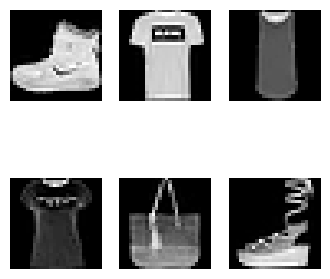

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(4, 4))

# Loop through each subplot and plot an image
for i in range(2):
    for j in range(3):
        image, label = train_set[i *34 + j]  # Get image and label
        image_numpy = image.numpy().squeeze()    # Convert image tensor to numpy array
        axs[i, j].imshow(image_numpy, cmap='gray')  # Plot the image
        axs[i, j].axis('off')  # Turn off axis
        #axs[i, j].set_title(f"Label: {label}")  # Set title with label

plt.show()  # Show plot

## Creemos el diccionario con nuestros labels y re imprimamos nuestras imagenes con los labels en texto:

In [11]:
label_dict = {
        0: "T-shirt/Top",
        1: "Trouser",
        2: "Pullover",
        3: "Dress",
        4: "Coat",
        5: "Sandal",
        6: "Shirt",
        7: "Sneaker",
        8: "Bag",
        9: "Ankle Boot"
        }

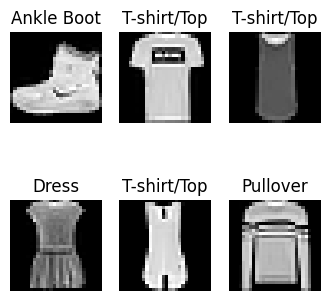

In [12]:
fig2, axs2 = plt.subplots(2, 3, figsize=(4, 4))
for i in range(2):
    for j in range(3):
        image, label = train_set[i * 3 + j]  # Get image and label
        image_numpy = image.numpy().squeeze()    # Convert image tensor to numpy array
        axs2[i, j].imshow(image_numpy, cmap='gray')  # Plot the image
        axs2[i, j].axis('off')  # Turn off axis
        axs2[i, j].set_title(f"{label_dict[label]}")  # Set title with label

plt.show()  # Show plot

## Ejercicio 3)

Creando un `DataLoader` para alimentar el modelo con batchs (lotes) de entrenamiento.

**1)** Cree los `DataLoader`s para cada conjunto. Defínalos con un `batch_size` de 100 y con el flag `shuffle` seteado a `True`.

**2)** Use uno de los `DataLoader`s creados anteriormente para explorar algunos elementos del conjunto.

Notar que, el iterador devuelve el batch en un par `(image,label)`.

El objeto `images` es un tensor de dimensiones `(100,1,28,28)`.
El 100 es el tamaño del batch.
El 1 porque hay un solo canal (en este caso, un canal de escala de grises, pero podría haber varios, p. ej. uno por cada color de {Red, Green Blue} en caso que fuesen imagenes a color).
Luego, 28 y 28 porque cada imagen del dataset es de 28 x 28 píxeles.

El objeto `labels` es un tensor de dimensiones `(100,)`.
La $i$-ésima entrada `labels[i]` de `labels` es un número en $\{0,1,...,9\}$ indicando la categoría a la que pertenece la $i$-ésima imagen en el batch, guardada en `images[i]`.

In [13]:
# 3.1)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = 100, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = 100, shuffle = True)

In [14]:
print(f"El dataset de entreamiento tiene: {train_loader.dataset}")
print(f"El dataset de testeo tiene: {test_loader.dataset}")

El dataset de entreamiento tiene: Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: MNIST_data/
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )
El dataset de testeo tiene: Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: MNIST_data/
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )


Feature batch shape: torch.Size([100, 1, 28, 28])
Labels batch shape: torch.Size([100])


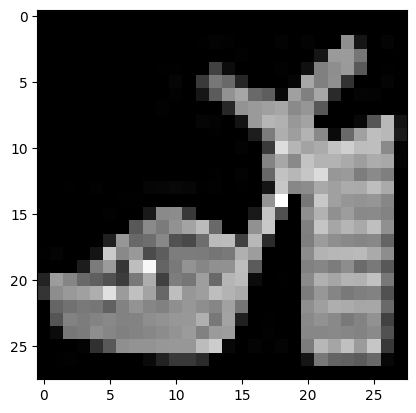

Label: Sandal
Feature batch shape: torch.Size([100, 1, 28, 28])
Labels batch shape: torch.Size([100])


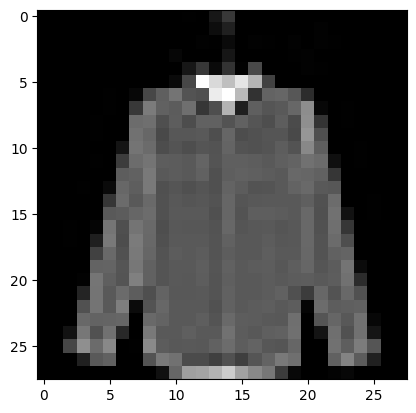

Label: Shirt
Feature batch shape: torch.Size([100, 1, 28, 28])
Labels batch shape: torch.Size([100])


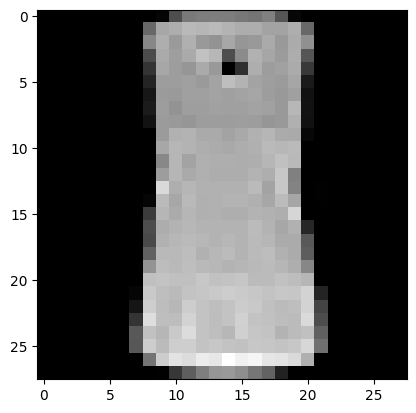

Label: T-shirt/Top
Feature batch shape: torch.Size([100, 1, 28, 28])
Labels batch shape: torch.Size([100])


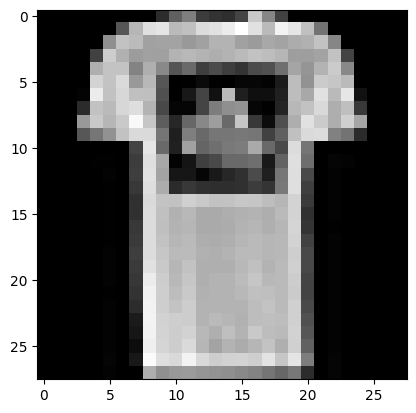

Label: T-shirt/Top
Feature batch shape: torch.Size([100, 1, 28, 28])
Labels batch shape: torch.Size([100])


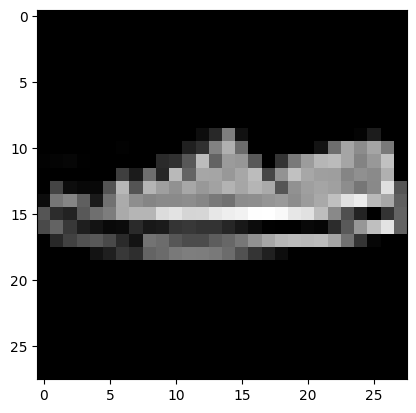

Label: Sneaker


In [15]:
for i in range(5):
  train_features, train_labels = next(iter(train_loader))
  print(f"Feature batch shape: {train_features.size()}") # Shape del batch y de los features
  print(f"Labels batch shape: {train_labels.size()}") # Shape del label
  img = train_features[0].squeeze() # Convertimos a numpy
  label = train_labels[0]
  plt.imshow(img, cmap="gray")
  plt.show()
  print(f"Label: {label_dict[label.item()]}")

## Ejercicio 4)

Defina una red neuronal de 4 capas, una de entrada, dos ocultas de $n_1=128$ y $n_2=64$ neuronas, respectivamente, y una de salida de 10 neuronas.

En las capas intermedias utilice neuronas tipo ReLU y agregueles un *dropout* de p=0.2.
En la capa de salida no utilice funciones de activación ni dropout.

Las capas sucesivas tienen que estar totalmente conectadas entre si.

In [16]:
# 4)
class NeuralNet(nn.Module):
  def __init__(self, n1, n2, p):
    super(NeuralNet, self).__init__()
    self.flatten = nn.Flatten() # capa para aplanar nuestra imagen
    self.linear_relu = nn.Sequential(
        # Capa 1
        nn.Linear(28*28, n1), # Input de 784 features, con 128 salidas
        nn.ReLU(), # Funcion de activacion
        nn.Dropout(p),
        # Capa 2
        nn.Linear(n1, n2), # Capa con 128 entradas y 64 salidas
        nn.ReLU(), # Funcion de activacion
        nn.Dropout(p),
        # Capa 3
        nn.Linear(n2,10), # Capa final con 10 salidas
        )

  def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu(x)
        return logits

In [17]:
model = NeuralNet(128,64, 0.2)
print(model)

NeuralNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


## Ejercicio 5)

Entrenamos el modelo

**1)** Implemente, en una función, un loop de entrenamiento que recorra los batchs (lotes).

**2)** Implemente, en una función, un loop de validación que recorra los batchs.

**3)** Inicialize dos `DataLoader`s llamados `train_loader` y `valid_loader` a partir del `train_set` (conjunto de entranmiento) y del `valid_set` (conjunto de validación) de Fashion-MNIST, respectivamente, y que usen batchs de 100 ejemplos.

**4)** Cree una función de pérdida usando la **Cross Entropy Loss**.

**IMPORTANTE:** Notar que la **Cross Entropy Loss** aplica automáticamente una `log_softmax`.

**5)** Cree un optimizador que utilice el método de **Stochastic Gradient Descent** con un learning rate igual a $10^{-3}$.

**6)** Cree una instancia del modelo.

**7)** Especifique en que dispositivo (`device`) va a trabajar: en una **CPU** o en una **GPU**.

**8)** Implemente un loop de entrenamiento y validación que trabaje con el `train_loader` y el `valid_loader`, respectivamente, usando un numero arbitrario de épocas.
Este loop debe guardar en cuatro listas los valores de los promedios del **Cross Entropy Loss** y las fracciones de clasificaciones correctas o **precisión** (accuracy) sobre el conjunto de **entrenamiento** y el de **validación**, respectivamente.

**IMPORTANTE:** No olvide copiar los batchs al dispositivo de trabajo.

**9)** Entrene y valide el modelo.

**10)** Use las listas del inciso anterior para graficar en función de las épocas la **Cross Entropy Loss** de **entrenamiento** y de **validación**.
Realize un gráfico análogo pero con la **precisión**.
Discuta y comente, cual es el número óptimo de épocas de entrenamiento?

**11)** Repita los experimentos variando hiperparámetros. Por ejemplo:

- El learning-rate.
- El optimizador (ej. puede usar ADAM).
- El valor de dropout.
- El número de neuronas en las capas intermedias.
- El número de épocas de entrenamiento.
- El tamaño de los lotes.

Discuta los resultados.

In [28]:
# 5.1)

def train(train_loader, my_model, loss_function, optimizer):
    my_model.train() # Establecemos que el modelo se va a entrenar (Esto hace que ciertas capas tenga el comportamiento deseado. Por ejemplo la de Dropout)
    sum_loss = 0
    sum_correct = 0
    sum_samples = 0
    num_batches = len(train_loader)
    for batch, (X,y) in enumerate(train_loader):
        # Enviamos los datos a nuestro dispositivo (CPU o GPU)
        X = X.to(device)
        y = y.to(device)
        #print(f"Estamos usando: {device}")
        sum_samples += len(X)

        # Predecimos con nuestro modelo
        y_train_pred = my_model(X)
        # Calculamos nuestra loss con la funcion dada
        loss = loss_function(y_train_pred, y)


        # ACTUALIZACION GRADIENTES:

        # Borramos los gradientes del batch anterior, para que no se sumen con el anterior
        optimizer.zero_grad()
        # Calculamos cuando debe cambiar (gradiente) los pesos para disminuir el error
        loss.backward()
        # Actualizamos los pesos
        optimizer.step()


        # METRICAS:

        # Calculamos nuestro loss por batches
        sum_loss += loss.item() * len(X)
        # Vemos cual prediccion es correcta o no y llevamos la cuenta de las corectas:
        sum_correct += (y_train_pred.argmax(1) == y).type(torch.float).sum().item()



        if batch % (num_batches/10) == 0:
            avrg_loss = sum_loss/sum_samples
            precision = sum_correct/sum_samples

    avrg_loss = sum_loss/sum_samples
    precision = sum_correct/sum_samples
    return avrg_loss, precision


In [29]:
# 5.2)

# Definimos la funcion de testeo

def test(test_loader, my_model, loss_function):
    # Entramos en modo testeo, al igual que en modo train, se restringen algunas funciones.
    my_model.eval()
    sum_correct = 0
    sum_samples = 0
    sum_loss = 0
    num_batches = len(test_loader)
    all_preds = []
    all_labels = []
    # Desactivamos el calculo de gradiente:
    with torch.no_grad():
        for X, y in test_loader:
            X.to(device)
            y.to(device)
            sum_samples += len(X)
            # Predecimos con nuestro modelo
            pred_test = my_model(X)
            # Calculamos el error:
            loss = loss_function(pred_test, y)
            sum_loss += loss.item() * len(X)
            sum_correct += (pred_test.argmax(1) == y).type(torch.float).sum().item()
            all_preds.extend(pred_test.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)        
    avrg_loss = sum_loss/sum_samples
    precision = sum_correct/sum_samples
    return avrg_loss, precision, cm


In [18]:
# 5.3)
batch_size = 100
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True)

In [19]:
# 5.4) # Creamos nuestra funcion de perdida:
loss_function = nn.CrossEntropyLoss()

In [20]:
# 5.6)
n1 = 128 # Cantidad de neuronas en la primera capa
n2 = 64 # Cantidad de neuronas en la segunda capa
p = 0.2 # 20% de dropout de neuronas
my_model = NeuralNet(n1,n2, p)

In [27]:
#5.5)
lr = 1e-3
first_optimizer = torch.optim.SGD(my_model.parameters(), lr=lr)

In [25]:
#5.7)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#my_model = my_model.to(device)

In [24]:
# 5.8)
epochs = 10
list_train_avg_loss = []
list_test_avg_loss = []
list_train_accuracy = []
list_test_accuracy = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n------------------------------")
    train_avg_loss_inc, train_acc_inc = train(train_loader,
                                                 my_model,
                                                 loss_function,
                                                 first_optimizer)
    train_avg_loss, train_acc, cm = test(train_loader,
                                        my_model,
                                        loss_function)

    test_avg_loss, test_acc, cm = test(test_loader,
                                        my_model,
                                        loss_function)

    list_train_avg_loss.append(train_avg_loss)
    list_test_avg_loss.append(test_avg_loss)

    list_train_accuracy.append(train_acc)
    list_test_accuracy.append(test_acc)

Epoch 1
------------------------------


NameError: name 'first_optimizer' is not defined

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(6, 6))  # (filas, columnas)

# --- Subplot 1: Loss ---
ax[0].set_title('Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].plot(range(1, len(list_train_avg_loss)+1), list_train_avg_loss, label='train', linestyle='--', c='green')
ax[0].plot(range(1, len(list_test_avg_loss)+1), list_test_avg_loss, label='test', linestyle='--', c='blue')
ax[0].legend()
ax[0].grid(True)

# --- Subplot 2: Accuracy ---
ax[1].set_title('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].plot(range(1, len(list_train_accuracy)+1), list_train_accuracy, label='train', linestyle='--', c='green')
ax[1].plot(range(1, len(list_test_accuracy)+1), list_test_accuracy, label='test', linestyle='--', c='blue')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()  # ajusta automáticamente los espacios entre subplots
plt.show()

## Variamos los hiperparametros:

In [21]:
def train_test(train_loader, test_loader, loss_function, model, optimizer, epochs):
    epochs = epochs
    list_train_avg_loss = []
    list_test_avg_loss = []
    list_train_accuracy = []
    list_test_accuracy = []
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n------------------------------")
        train_avg_loss_inc, train_acc_inc = train(train_loader,
                                                     model,
                                                     loss_function,
                                                     optimizer)
        train_avg_loss, train_acc, cm_train = test(train_loader,
                                            model,
                                            loss_function)

        test_avg_loss, test_acc, cm_test = test(test_loader,
                                            model,
                                            loss_function)

        list_train_avg_loss.append(train_avg_loss)
        list_test_avg_loss.append(test_avg_loss)

        list_train_accuracy.append(train_acc)
        list_test_accuracy.append(test_acc)

    return (list_train_avg_loss, list_test_avg_loss, list_train_accuracy, list_test_accuracy, cm_test)

In [69]:
def plot_curves(list_train_avg_loss, list_test_avg_loss, list_train_accuracy, list_test_accuracy, cm_test):
    fig, ax = plt.subplots(2, 1, figsize=(6, 6))  # (filas, columnas)

    # --- Subplot 1: Loss ---
    ax[0].set_title('Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].plot(range(1, len(list_train_avg_loss)+1), list_train_avg_loss, label='train', linestyle='-.', c='blue')
    ax[0].plot(range(1, len(list_test_avg_loss)+1), list_test_avg_loss, label='test', linestyle='--', c='red')
    ax[0].legend()
    ax[0].grid(True)

    # --- Subplot 2: Accuracy ---
    ax[1].set_title('Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].plot(range(1, len(list_train_accuracy)+1), list_train_accuracy, label='train', linestyle='-.', c='blue')
    ax[1].plot(range(1, len(list_test_accuracy)+1), list_test_accuracy, label='test', linestyle='--', c='red')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()  # ajusta automáticamente los espacios entre subplots
    

    
    plt.show()


In [23]:
def plot_curves1(list_train_loss, list_test_loss, list_train_acc, list_test_acc):
    fig, ax = plt.subplots(2, 1, figsize=(6, 6))

    epochs = range(1, len(list_train_loss) + 1)

    # --- Subplot 1: Loss ---
    ax[0].set_title('Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].plot(
        epochs,
        list_train_loss,
        label='train',
        linestyle='-',
        marker='x',
        markersize=6,
        linewidth=1,
        c='red'
    )
    ax[0].plot(
        epochs,
        list_test_loss,
        label='test',
        linestyle='--',
        c='green',
        linewidth=1
    )
    ax[0].legend()
    ax[0].grid(True)

    # --- Subplot 2: Accuracy ---
    ax[1].set_title('Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].plot(
        epochs,
        list_train_acc,
        label='train',
        linestyle='-',
        marker='x',
        markersize=6,
        linewidth=1,
        c='red'
    )
    ax[1].plot(
        epochs,
        list_test_acc,
        label='test',
        linestyle='--',
        c='blue',
        linewidth=1
    )
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

In [28]:
    cm_norm = cm.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
    disp.plot(cmap='Blues', values_format=".2f")
    plt.title("Matriz de confusión normalizada en test")

AttributeError: module 'matplotlib.cm' has no attribute 'astype'

### Veamos para distintos learnings rates:

In [ ]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA")

In [ ]:
lr_1 = 5
lr_2 = 1
lr_3 = 0.1
lr_4 = 0.0001
lr_5 = 0.000000001

In [ ]:
print(device)

In [ ]:
a

In [ ]:
b

In [ ]:
c

In [ ]:
d

In [ ]:
a= []
b= []
c= []
d= []

adam_optimizer = torch.optim.Adam(my_model.parameters(), lr=0.001)
a, b, c, d, cm = train_test(train_loader,test_loader, loss_function, my_model, adam_optimizer, epochs = 5)

In [ ]:
plot_curves1(a, b,c, d)

In [ ]:
cm

## Test para Learning Rates:

In [29]:
lr_1 = 5
lr_2 = 1
lr_3 = 0.1
lr_4 = 0.0001
lr_5 = 0.000000001


🔹 Entrenando con learning rate = 1
Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
----

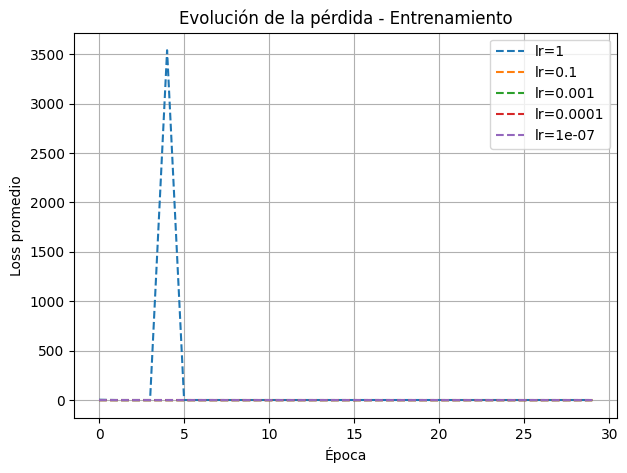

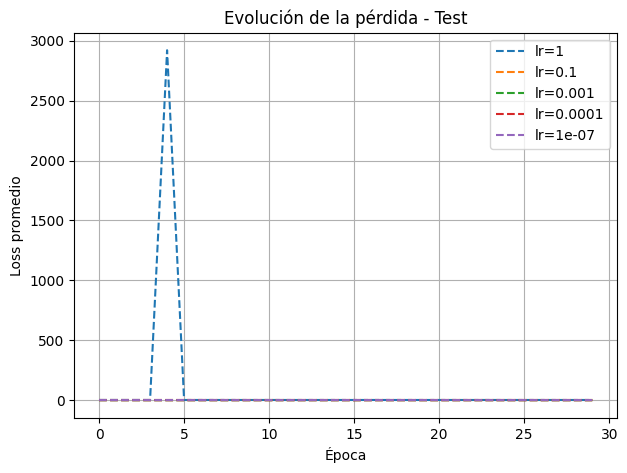

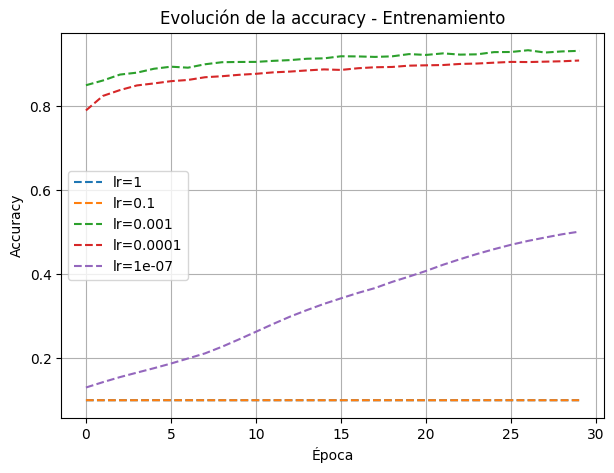

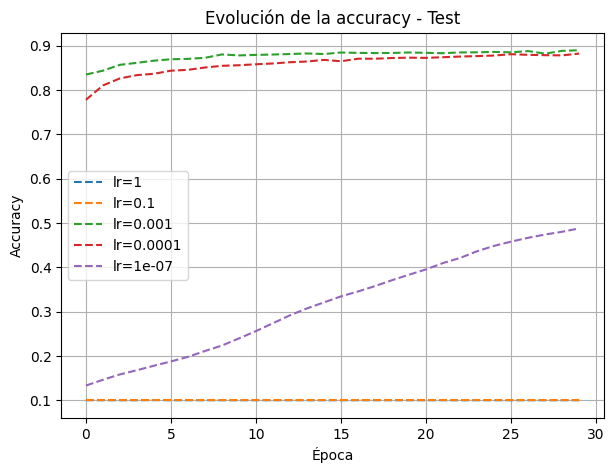

In [33]:
loss_function = nn.CrossEntropyLoss()
learning_rates = [1, 0.1, 0.001, 0.0001, 0.0000001]
epochs = 30

# Diccionarios para guardar resultados
results = {}

# ------------------------------------------------------
# BUCLE PRINCIPAL: probar varios learning rates
# ------------------------------------------------------
for lr in learning_rates:
    print(f"\n🔹 Entrenando con learning rate = {lr}")
    # Crear modelo NUEVO para cada experimento
    model = NeuralNet(n1, n2, p).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Entrenar y testear
    train_loss, test_loss, train_acc, test_acc, cm = train_test(
        train_loader, test_loader, loss_function, model, optimizer, epochs
    )

    # Guardar resultados
    results[lr] = {
        "train_loss": train_loss,
        "test_loss": test_loss,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "cm": cm
    }

# ------------------------------------------------------
# VISUALIZAR RESULTADOS
# ------------------------------------------------------
import matplotlib.pyplot as plt

# --------------------------
# 1. Pérdida de entrenamiento
# --------------------------
plt.figure(figsize=(7,5))
for lr, data in results.items():
    plt.plot(data["train_loss"], label=f"lr={lr}", linestyle='--')
plt.title("Evolución de la pérdida - Entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 2. Pérdida de test
# --------------------------
plt.figure(figsize=(7,5))
for lr, data in results.items():
    plt.plot(data["test_loss"], label=f"lr={lr}", linestyle='--')
plt.title("Evolución de la pérdida - Test")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 3. Accuracy de entrenamiento
# --------------------------
plt.figure(figsize=(7,5))
for lr, data in results.items():
    plt.plot(data["train_acc"], label=f"lr={lr}", linestyle='--')
plt.title("Evolución de la accuracy - Entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 4. Accuracy de test
# --------------------------
plt.figure(figsize=(7,5))
for lr, data in results.items():
    plt.plot(data["test_acc"], label=f"lr={lr}", linestyle='--')
plt.title("Evolución de la accuracy - Test")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
batch_size = 100
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True)

0.2

### Variamos Epochs


🔹 Entrenando con 100 batch
Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------

Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------------------------
Epoch 26
------------------------------
Epoch 27

Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------------------------
Epoch 26
------------------------------
Epoch 27

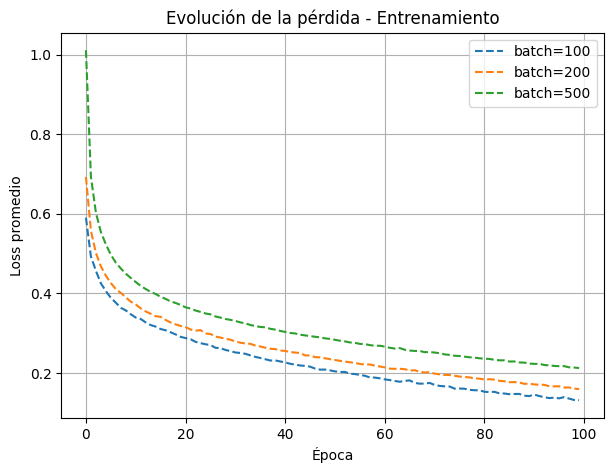

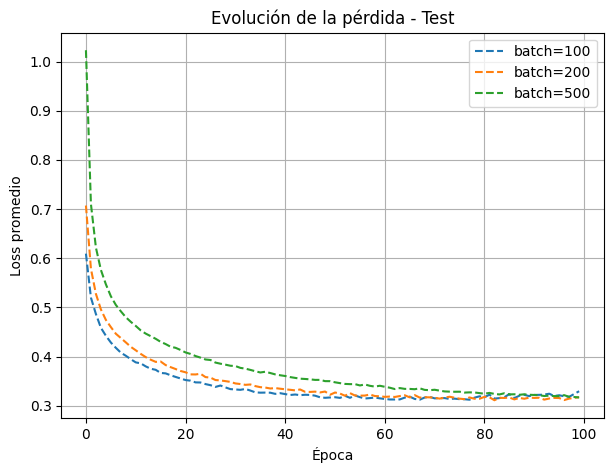

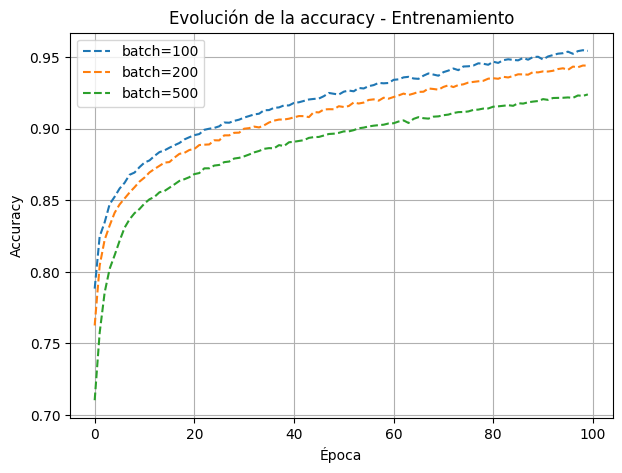

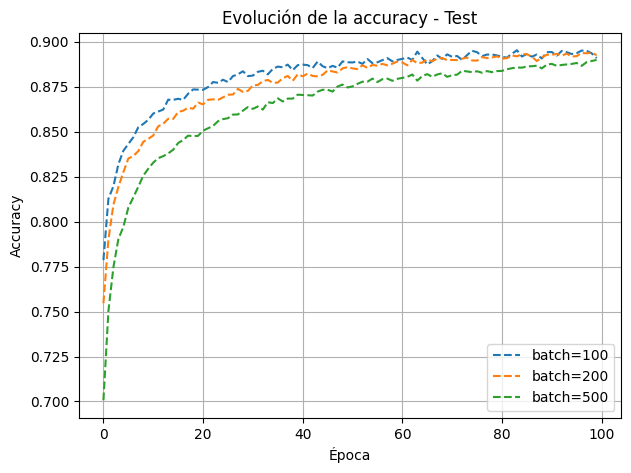

In [43]:
loss_function = nn.CrossEntropyLoss()
epochs = 100
batches = [100, 200, 500]

results = {}

# ------------------------------------------------------
# BUCLE PRINCIPAL: probar varios Epochs
# ------------------------------------------------------
for batch in batches:
    print(f"\n🔹 Entrenando con {batch} batch")
    model = NeuralNet(n1, n2, p).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    train_loader = DataLoader(train_set, batch_size=batch, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch, shuffle=True)

    # Entrenar y testear
    train_loss, test_loss, train_acc, test_acc, cm = train_test(
        train_loader, test_loader, loss_function, model, optimizer, epochs
    )

    results[batch] = {
        "train_loss": train_loss,
        "test_loss": test_loss,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "cm": cm
    }
    print(results[batch])
# ------------------------------------------------------
# Mostrar solo la última época (la más alta)
# ------------------------------------------------------
# --------------------------
# 1. Pérdida de entrenamiento
# --------------------------
plt.figure(figsize=(7,5))
for batch, data in results.items():
    plt.plot(data["train_loss"], label=f"batch={batch}", linestyle='--')
plt.title("Evolución de la pérdida - Entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 2. Pérdida de test
# --------------------------
plt.figure(figsize=(7,5))
for batch, data in results.items():
    plt.plot(data["test_loss"], label=f"batch={batch}", linestyle='--')
plt.title("Evolución de la pérdida - Test")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 3. Accuracy de entrenamiento
# --------------------------
plt.figure(figsize=(7,5))
for batch, data in results.items():
    plt.plot(data["train_acc"], label=f"batch={batch}", linestyle='--')
plt.title("Evolución de la accuracy - Entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 4. Accuracy de test
# --------------------------
plt.figure(figsize=(7,5))
for batch, data in results.items():
    plt.plot(data["test_acc"], label=f"batch={batch}", linestyle='--')
plt.title("Evolución de la accuracy - Test")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Variemos DropOut:

In [36]:
loss_function = nn.CrossEntropyLoss()
dropout_list = [0, 0.2, 0.5, 0.9]
epochs = 30

# Diccionarios para guardar resultados
results = {}

# ------------------------------------------------------
# BUCLE PRINCIPAL: probar varios learning rates
# ------------------------------------------------------
for dropout in dropout_list:
    print(f"\n🔹 Entrenando con dropout = {dropout}")
    # Crear modelo NUEVO para cada experimento
    model = NeuralNet(n1, n2, dropout).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Entrenar y testear
    train_loss, test_loss, train_acc, test_acc, cm = train_test(
        train_loader, test_loader, loss_function, model, optimizer, epochs
    )

    # Guardar resultados
    results[dropout] = {
        "train_loss": train_loss,
        "test_loss": test_loss,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "cm": cm
    }

# ------------------------------------------------------
# VISUALIZAR RESULTADOS
# ------------------------------------------------------
import matplotlib.pyplot as plt

# --------------------------
# 1. Pérdida de entrenamiento
# --------------------------
plt.figure(figsize=(7,5))
for dropout, data in results.items():
    plt.plot(data["train_loss"], label=f"dropout={dropout}", linestyle='--')
plt.title("Evolución de la pérdida - Entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 2. Pérdida de test
# --------------------------
plt.figure(figsize=(7,5))
for dropout, data in results.items():
    plt.plot(data["test_loss"], label=f"dropout={dropout}", linestyle='--')
plt.title("Evolución de la pérdida - Test")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 3. Accuracy de entrenamiento
# --------------------------
plt.figure(figsize=(7,5))
for dropout, data in results.items():
    plt.plot(data["train_acc"], label=f"dropout={dropout}", linestyle='--')
plt.title("Evolución de la accuracy - Entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 4. Accuracy de test
# --------------------------
plt.figure(figsize=(7,5))
for dropout, data in results.items():
    plt.plot(data["test_acc"], label=f"dropout={dropout}", linestyle='--')
plt.title("Evolución de la accuracy - Test")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


🔹 Entrenando con dropout = 0
Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------


KeyboardInterrupt: 

## Cambiemos nuestra arquitectura.

In [ ]:
# original con 128 y 64


🔹 Entrenando con n1 = 64 y n2 = 32
Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
----

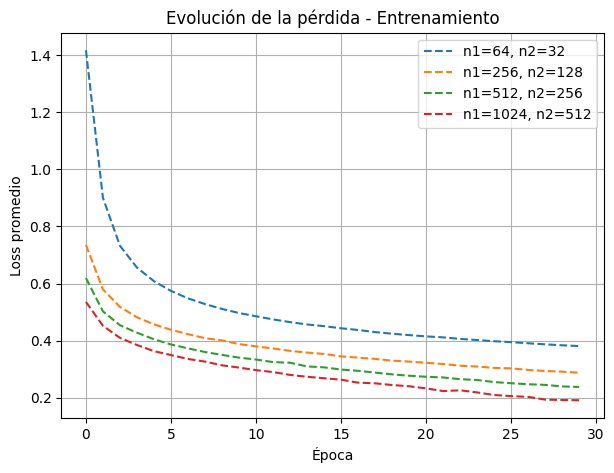

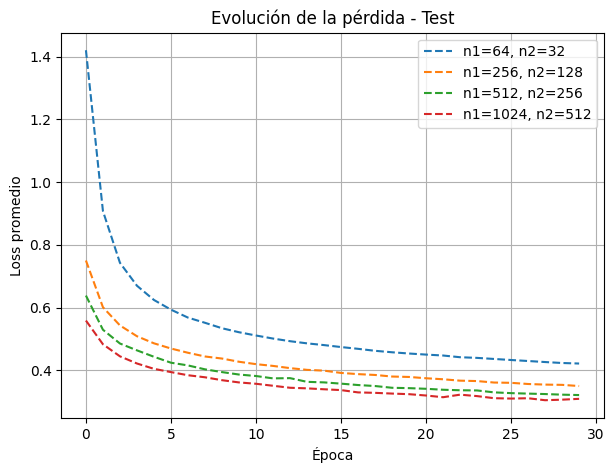

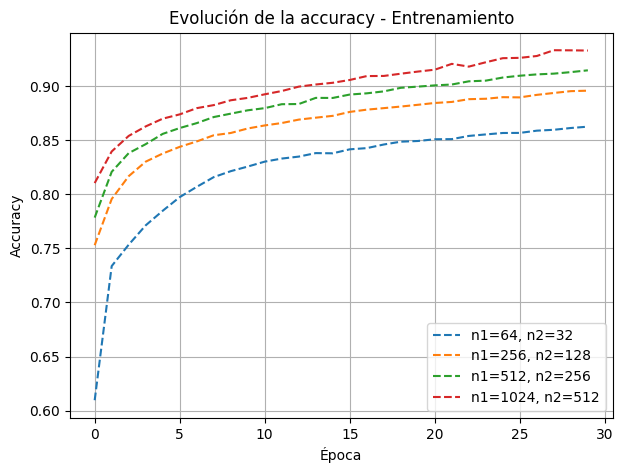

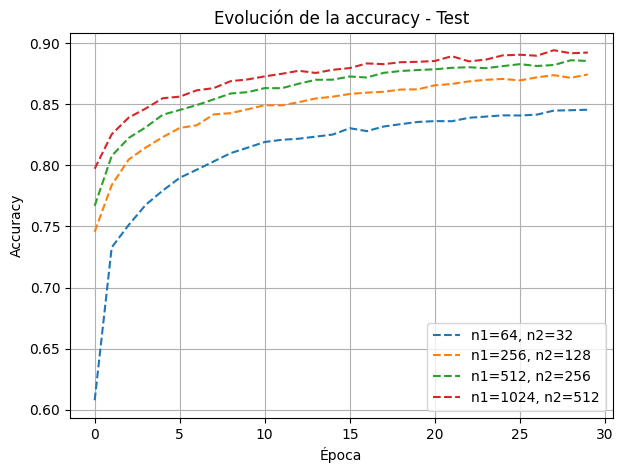

In [47]:
loss_function = nn.CrossEntropyLoss()
n1_list = [64, 256, 512, 1024]
n2_list = [32, 128, 256, 512]
epochs = 30

# Diccionario para guardar resultados
results = {}

# ------------------------------------------------------
# BUCLE PRINCIPAL: probar varias configuraciones
# ------------------------------------------------------
for i, (n1, n2) in enumerate(zip(n1_list, n2_list)):
    print(f"\n🔹 Entrenando con n1 = {n1} y n2 = {n2}")
    
    # Crear modelo NUEVO para cada experimento
    model = NeuralNet(n1, n2, 0.2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    # Entrenar y testear
    train_loss, test_loss, train_acc, test_acc, cm = train_test(
        train_loader, test_loader, loss_function, model, optimizer, epochs
    )

    # Guardar resultados con ambos parámetros
    results[(n1, n2)] = {
        "train_loss": train_loss,
        "test_loss": test_loss,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "cm": cm
    }

# ------------------------------------------------------
# VISUALIZAR RESULTADOS
# ------------------------------------------------------
import matplotlib.pyplot as plt

# --------------------------
# 1. Pérdida de entrenamiento
# --------------------------
plt.figure(figsize=(7,5))
for (n1, n2), data in results.items():
    plt.plot(data["train_loss"], label=f"n1={n1}, n2={n2}", linestyle='--')
plt.title("Evolución de la pérdida - Entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 2. Pérdida de test
# --------------------------
plt.figure(figsize=(7,5))
for (n1, n2), data in results.items():
    plt.plot(data["test_loss"], label=f"n1={n1}, n2={n2}", linestyle='--')
plt.title("Evolución de la pérdida - Test")
plt.xlabel("Época")
plt.ylabel("Loss promedio")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 3. Accuracy de entrenamiento
# --------------------------
plt.figure(figsize=(7,5))
for (n1, n2), data in results.items():
    plt.plot(data["train_acc"], label=f"n1={n1}, n2={n2}", linestyle='--')
plt.title("Evolución de la accuracy - Entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------
# 4. Accuracy de test
# --------------------------
plt.figure(figsize=(7,5))
for (n1, n2), data in results.items():
    plt.plot(data["test_acc"], label=f"n1={n1}, n2={n2}", linestyle='--')
plt.title("Evolución de la accuracy - Test")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## Entrenemos el modelo una ultima vez

In [114]:
n1_t = 512 # Cantidad de neuronas en la primera capa
n2_t = 256 # Cantidad de neuronas en la segunda capa
p_t = 0.2 # 20% de dropout de neuronas

train_loss_t = []
test_loss_t = []
train_acc_t = []
test_acc_t = []
epochs_t = 30
model_t = NeuralNet(n1_t, n2_t, 0.5).to(device)
loss_function_t = nn.CrossEntropyLoss()
train_loader = DataLoader(train_set, batch_size=100, shuffle=True)
test_loader = DataLoader(test_set, batch_size=100, shuffle=True)
optimizer = torch.optim.Adam(model_t.parameters(), lr=0.0001)
train_loss_t, test_loss_t, train_acc_t, test_acc_t, cm_t = train_test(
        train_loader, test_loader, loss_function_t, model_t, optimizer, epochs_t)

Epoch 1
------------------------------
Epoch 2
------------------------------
Epoch 3
------------------------------
Epoch 4
------------------------------
Epoch 5
------------------------------
Epoch 6
------------------------------
Epoch 7
------------------------------
Epoch 8
------------------------------
Epoch 9
------------------------------
Epoch 10
------------------------------
Epoch 11
------------------------------
Epoch 12
------------------------------
Epoch 13
------------------------------
Epoch 14
------------------------------
Epoch 15
------------------------------
Epoch 16
------------------------------
Epoch 17
------------------------------
Epoch 18
------------------------------
Epoch 19
------------------------------
Epoch 20
------------------------------
Epoch 21
------------------------------
Epoch 22
------------------------------
Epoch 23
------------------------------
Epoch 24
------------------------------
Epoch 25
------------------------------
Epoch 26


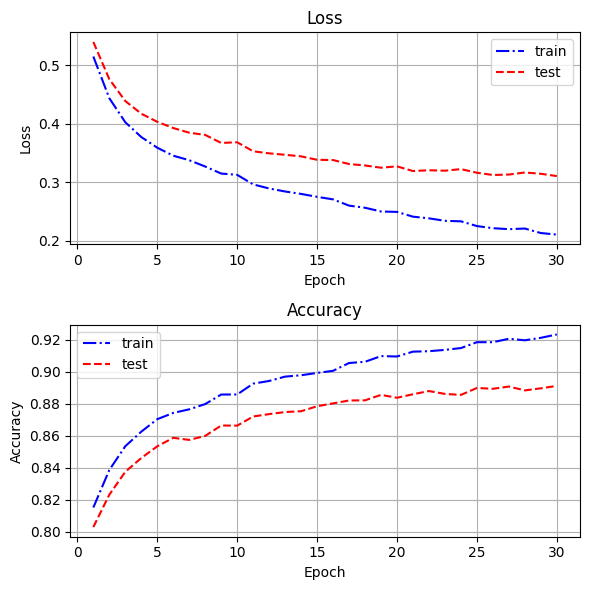

In [115]:
plot_curves(train_loss_t, test_loss_t, train_acc_t, test_acc_t, cm_t)

In [116]:
cm_t

array([[845,   1,  21,  28,   6,   2,  92,   0,   5,   0],
       [  1, 970,   0,  22,   3,   0,   3,   0,   1,   0],
       [ 11,   0, 824,  16,  80,   1,  67,   0,   1,   0],
       [ 17,   6,  12, 907,  38,   0,  17,   0,   3,   0],
       [  0,   1,  75,  27, 845,   0,  52,   0,   0,   0],
       [  0,   0,   0,   1,   0, 946,   0,  28,   2,  23],
       [121,   2,  80,  28,  69,   0, 690,   0,  10,   0],
       [  0,   0,   0,   0,   0,  16,   0, 941,   0,  43],
       [  3,   0,   2,   6,   3,   4,   3,   5, 974,   0],
       [  0,   0,   0,   0,   0,   5,   1,  25,   0, 969]], dtype=int64)

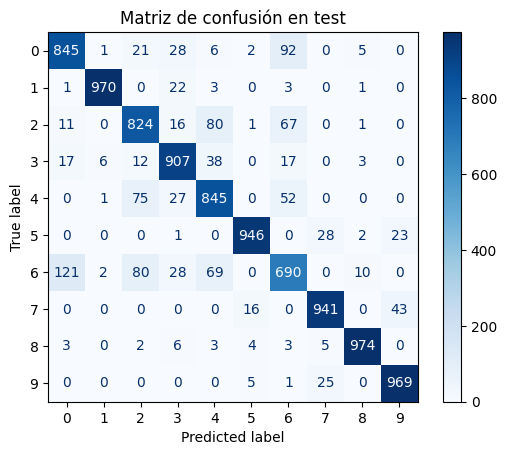

In [117]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_t)
disp.plot(cmap='Blues', values_format="d")
plt.title("Matriz de confusión en test")
plt.show()

In [118]:
test_acc_t[-1]

0.8911

In [ ]:
0.8921